# Обнаружение мошенничества в банковских транзакциях

Модель классификации для выявления мошеннических транзакций с использованием CatBoost.
Данные агрегированы на уровне клиентов для надежного предсказания мошенничества.

## Часть 1: Настройка окружения

Инициализация зависимостей, логирования и параметров визуализации.

In [1]:
import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, roc_curve,
    f1_score, fbeta_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, classification_report,
    average_precision_score
)

# Настройка
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Настройки визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
logger.info("Окружение инициализировано")

2026-05-11 11:15:15,477 - INFO - Окружение инициализировано


## Часть 2: Загрузка и исследование данных

Загрузка тренировочного и тестового наборов, анализ структуры и распределения мошенничества.

In [2]:
from pathlib import Path

DATA_DIR = Path("../data")

df_train = pd.read_csv(DATA_DIR / "train_clean.csv", index_col=False)
df_val = pd.read_csv(DATA_DIR / "val_clean.csv", index_col=False)
df_test = pd.read_csv(DATA_DIR / "test_clean.csv", index_col=False)

logger.info(f"Train: {df_train.shape[0]:,} строк x {df_train.shape[1]} колонок")
logger.info(f"Val:   {df_val.shape[0]:,} строк x {df_val.shape[1]} колонок")
logger.info(f"Test:  {df_test.shape[0]:,} строк x {df_test.shape[1]} колонок")

logger.info(f"Доля мошенничества train: {df_train['FraudResult'].mean():.2%}")
logger.info(f"Доля мошенничества val:   {df_val['FraudResult'].mean():.2%}")
logger.info(f"Доля мошенничества test:  {df_test['FraudResult'].mean():.2%}")

print("\nСводка по данным:")
print(f"  Источник:      {DATA_DIR}")
print(f"  Train строк:   {df_train.shape[0]:>8,}")
print(f"  Val строк:     {df_val.shape[0]:>8,}")
print(f"  Test строк:    {df_test.shape[0]:>8,}")
print(f"  Колонок:       {df_train.shape[1]:>8}")


2026-05-11 11:15:15,589 - INFO - Train: 57,364 строк x 24 колонок
2026-05-11 11:15:15,589 - INFO - Val:   19,162 строк x 24 колонок
2026-05-11 11:15:15,589 - INFO - Test:  19,136 строк x 24 колонок
2026-05-11 11:15:15,592 - INFO - Доля мошенничества train: 0.20%
2026-05-11 11:15:15,592 - INFO - Доля мошенничества val:   0.21%
2026-05-11 11:15:15,593 - INFO - Доля мошенничества test:  0.20%



Сводка по данным:
  Источник:      ../data
  Train строк:     57,364
  Val строк:       19,162
  Test строк:      19,136
  Колонок:             24


### Анализ распределения сущностей

In [3]:
# Данные уже разделены на train, val и test
logger.info("Используются заранее подготовленные train_clean.csv, val_clean.csv и test_clean.csv")

2026-05-11 11:15:15,597 - INFO - Используются заранее подготовленные train_clean.csv, val_clean.csv и test_clean.csv


## Часть 3: Обработка признаков

Использование признаков, заранее подготовленных и закодированных в data/cleanup.ipynb.

### Использование подготовленных признаков

In [4]:
# Все признаки уже подготовлены в data/cleanup.ipynb.
train_prep = df_train.copy()
val_prep = df_val.copy()
test_prep = df_test.copy()

logger.info(f"Train подготовлен: {train_prep.shape}")
logger.info(f"Val подготовлен:   {val_prep.shape}")
logger.info(f"Test подготовлен:  {test_prep.shape}")


2026-05-11 11:15:15,609 - INFO - Train подготовлен: (57364, 24)
2026-05-11 11:15:15,610 - INFO - Val подготовлен:   (19162, 24)
2026-05-11 11:15:15,610 - INFO - Test подготовлен:  (19136, 24)


### Выбор признаков

In [5]:
TARGET_COL = "FraudResult"
CLIENT_ID_COL = "CustomerId"

cat_features = [
    "ProviderId_id",
    "ProductId_id",
    "ProductCategory_id",
    "ChannelId_id",
    "PricingStrategy_id",
]

feature_cols = [
    col for col in train_prep.columns
    if col not in {TARGET_COL, CLIENT_ID_COL}
]

logger.info(f"Выбрано признаков: {len(feature_cols)}")
logger.info(f"Категориальные признаки CatBoost: {cat_features}")

print(f"\nПризнаки: {', '.join(sorted(feature_cols))}")
print(f"Категориальные признаки CatBoost: {cat_features}")

X_train = train_prep[feature_cols].copy()
y_train = train_prep[TARGET_COL].copy()

X_val = val_prep[feature_cols].copy()
y_val = val_prep[TARGET_COL].copy()

X_test = test_prep[feature_cols].copy()
y_test = test_prep[TARGET_COL].copy()

logger.info(f"Train: {len(X_train):,} объектов, доля мошенничества {y_train.mean():.2%}")
logger.info(f"Val:   {len(X_val):,} объектов, доля мошенничества {y_val.mean():.2%}")
logger.info(f"Test:  {len(X_test):,} объектов, доля мошенничества {y_test.mean():.2%}")

print("\nРазмеры матриц:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_test:  {y_test.shape}")


2026-05-11 11:15:15,616 - INFO - Выбрано признаков: 22
2026-05-11 11:15:15,617 - INFO - Категориальные признаки CatBoost: ['ProviderId_id', 'ProductId_id', 'ProductCategory_id', 'ChannelId_id', 'PricingStrategy_id']
2026-05-11 11:15:15,621 - INFO - Train: 57,364 объектов, доля мошенничества 0.20%
2026-05-11 11:15:15,621 - INFO - Val:   19,162 объектов, доля мошенничества 0.21%
2026-05-11 11:15:15,621 - INFO - Test:  19,136 объектов, доля мошенничества 0.20%



Признаки: Amount, ChannelId_id, PricingStrategy_id, ProductCategory_id, ProductId_id, ProviderId_id, abs_amount, amount_sign, is_negative_amount, log_abs_amount, tx_day, tx_dayofweek, tx_dayofweek_cos, tx_dayofweek_sin, tx_elapsed_days, tx_elapsed_seconds, tx_hour, tx_hour_cos, tx_hour_sin, tx_is_weekend, tx_minute, tx_month
Категориальные признаки CatBoost: ['ProviderId_id', 'ProductId_id', 'ProductCategory_id', 'ChannelId_id', 'PricingStrategy_id']

Размеры матриц:
  X_train: (57364, 22)
  y_train: (57364,)
  X_val:   (19162, 22)
  y_val:   (19162,)
  X_test:  (19136, 22)
  y_test:  (19136,)


## Часть 4: Обучение модели

Обучение классификатора CatBoost с ранней остановкой и оптимизацией AUC.

In [6]:
logger.info("Обучение CatBoost...")

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=7,
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50,
    eval_metric='AUC',
    use_best_model=True
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    cat_features=cat_features,
    plot=False
)

logger.info("Обучение завершено")


2026-05-11 11:15:15,626 - INFO - Обучение CatBoost...


0:	test: 0.7949077	best: 0.7949077 (0)	total: 91.9ms	remaining: 1m 31s


2026-05-11 11:15:17,555 - INFO - Обучение завершено


Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9936839766
bestIteration = 27

Shrink model to first 28 iterations.


### Важность признаков


                     ВАЖНОСТЬ ПРИЗНАКОВ                     
           feature  importance
            Amount   16.139763
            tx_day   14.648179
        abs_amount   13.202515
         tx_minute   10.782586
           tx_hour    9.150364
       tx_hour_sin    6.242756
          tx_month    6.010065
  tx_dayofweek_cos    4.442891
    log_abs_amount    3.857660
   tx_elapsed_days    3.792406
       tx_hour_cos    3.689918
      tx_dayofweek    2.753703
  tx_dayofweek_sin    2.235810
     tx_is_weekend    1.702625
tx_elapsed_seconds    0.823769
is_negative_amount    0.425811
       amount_sign    0.099179
     ProviderId_id    0.000000
      ProductId_id    0.000000
ProductCategory_id    0.000000
      ChannelId_id    0.000000
PricingStrategy_id    0.000000


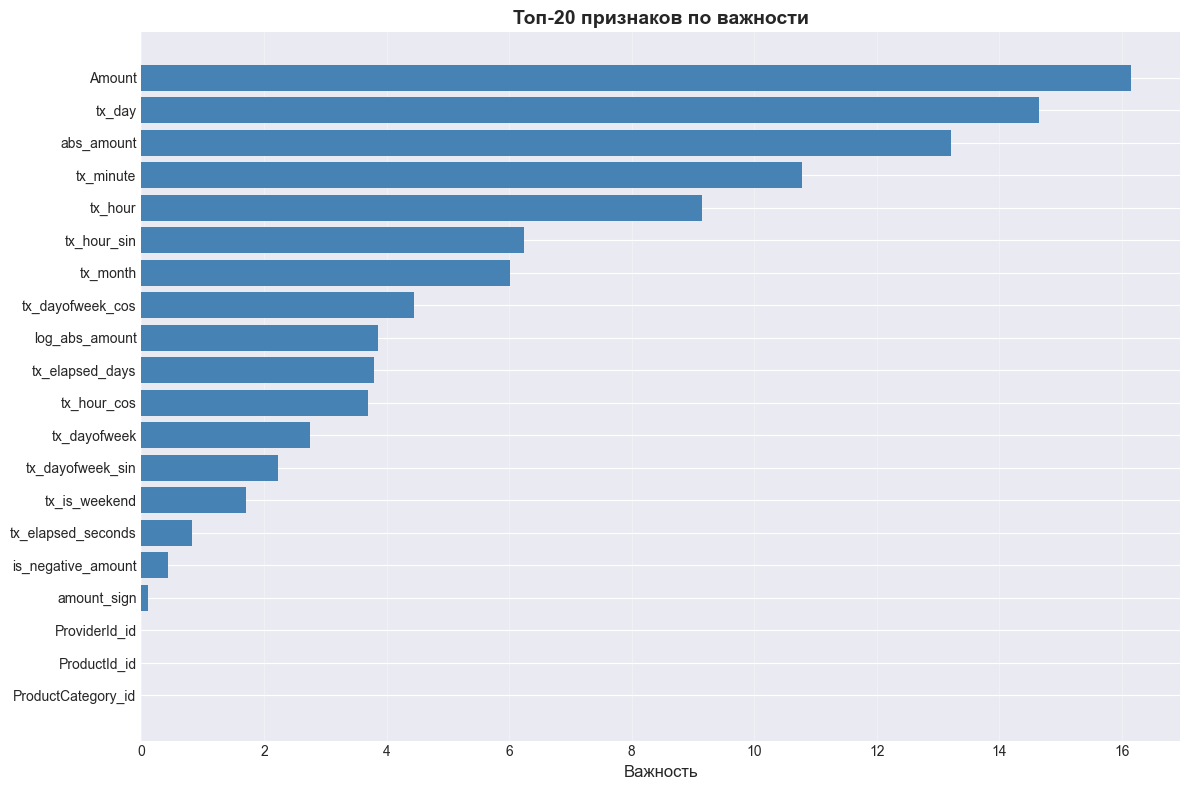

2026-05-11 11:15:17,796 - INFO - Выведено важности признаков: 22 признаков


In [7]:
# Анализ важности признаков
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.get_feature_importance()
}).sort_values('importance', ascending=False)

print("\n" + "=" * 60)
print("ВАЖНОСТЬ ПРИЗНАКОВ".center(60))
print("=" * 60)
print(feature_importance.to_string(index=False))

# Визуализация
fig, ax = plt.subplots(figsize=(12, 8))
top_n = min(20, len(feature_importance))
top_features = feature_importance.head(top_n)

ax.barh(range(len(top_features)), top_features['importance'].values, color='steelblue')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values)
ax.set_xlabel('Важность', fontsize=12)
ax.set_title(f'Топ-{top_n} признаков по важности', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

logger.info(f"Выведено важности признаков: {len(feature_importance)} признаков")

## Часть 5: Инференс модели

Генерация предсказаний для тестового набора на уровне транзакций и клиентов.

In [8]:
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Диагностическая информация
logger.info(f"Предсказания построены для {len(y_pred_proba):,} test-объектов")
logger.info(f"Статистика score - min: {y_pred_proba.min():.6f}, max: {y_pred_proba.max():.6f}, mean: {y_pred_proba.mean():.6f}")
logger.info(f"Score >= 0.5: {(y_pred_proba >= 0.5).sum()}")

y_pred = (y_pred_proba >= 0.5).astype(int)

2026-05-11 11:15:17,812 - INFO - Предсказания построены для 19,136 test-объектов
2026-05-11 11:15:17,812 - INFO - Статистика score - min: 0.000394, max: 0.952564, mean: 0.002976
2026-05-11 11:15:17,813 - INFO - Score >= 0.5: 45


### Агрегация на уровень клиентов

In [9]:
# Агрегация транзакционных предсказаний на уровень клиента
client_data = pd.DataFrame({
    CLIENT_ID_COL: test_prep[CLIENT_ID_COL].values,
    'y_true': y_test.values,
    'y_score': y_pred_proba
})

# Группируем по клиенту: берём максимальный score и наличие мошенничества
client_eval = client_data.groupby(CLIENT_ID_COL, as_index=False).agg({
    'y_true': 'max',
    'y_score': 'max'
})

client_eval.columns = [CLIENT_ID_COL, 'y_true_client', 'y_score_client']
client_eval['y_pred_client'] = (client_eval['y_score_client'] >= 0.5).astype(int)

logger.info(f"Агрегировано до {len(client_eval):,} уникальных клиентов")
logger.info(f"Истинных мошеннических клиентов: {(client_eval['y_true_client'] == 1).sum()}")
logger.info(f"Предсказано мошеннических клиентов: {(client_eval['y_pred_client'] == 1).sum()}")
logger.info(f"Статистика клиентских score - min: {client_eval['y_score_client'].min():.6f}, max: {client_eval['y_score_client'].max():.6f}, mean: {client_eval['y_score_client'].mean():.6f}")

2026-05-11 11:15:17,827 - INFO - Агрегировано до 749 уникальных клиентов
2026-05-11 11:15:17,828 - INFO - Истинных мошеннических клиентов: 11
2026-05-11 11:15:17,828 - INFO - Предсказано мошеннических клиентов: 13
2026-05-11 11:15:17,828 - INFO - Статистика клиентских score - min: 0.000444, max: 0.952564, mean: 0.017747


## Часть 6: Оценка модели

2026-05-11 11:15:17,840 - INFO - Используется фиксированный порог: 0.50



         ОТЧЕТ ОБ ОЦЕНКЕ МОДЕЛИ CATBOOST (АГРЕГАЦИЯ НА УРОВНЕ КЛИЕНТОВ)         

СТАТИСТИКА НАБОРА ДАННЫХ:
--------------------------------------------------------------------------------
  Всего клиентов:                       749    (100.0%)
  Мошенники:                             11    (  1.5%)
  Честные:                              738    ( 98.5%)

РАСПРЕДЕЛЕНИЕ ПРЕДСКАЗАНИЙ:
--------------------------------------------------------------------------------
  Предсказано как мошенник:             13    (  1.7%)
  Предсказано как честный:             736    ( 98.3%)
  Порог:                             0.5000

МАТРИЦА ОШИБОК:
--------------------------------------------------------------------------------
  Истинные негативы (TN):               734
  Ложные позитивы (FP):                   4
  Ложные негативы (FN):                   2
  Истинные позитивы (TP):                 9

МЕТРИКИ КАЧЕСТВА:
--------------------------------------------------------------------------------
  Ac

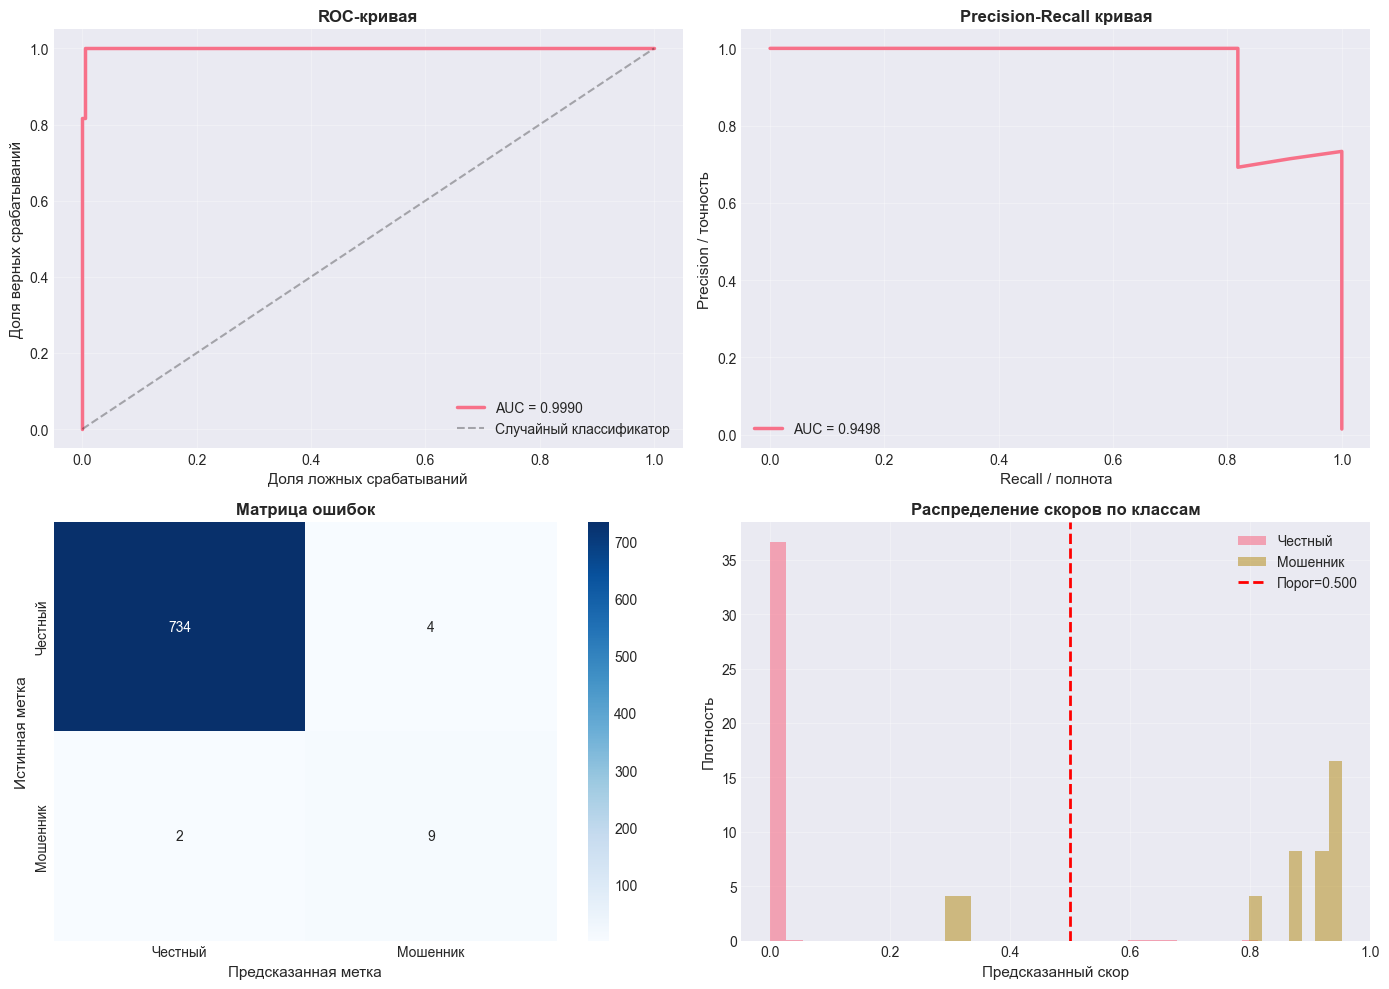

2026-05-11 11:15:18,066 - INFO - Оценка модели завершена успешно


In [10]:
y_true = client_eval['y_true_client'].values
y_score = client_eval['y_score_client'].values

# Используем фиксированный порог 0.5 без подбора
optimal_thresh = 0.5
y_pred = (y_score >= optimal_thresh).astype(int)

logger.info(f"Используется фиксированный порог: {optimal_thresh:.2f}")

# Расчет метрик
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

metrics = {
    'ROC-AUC': roc_auc_score(y_true, y_score),
    'PR-AUC': average_precision_score(y_true, y_score),
    'Accuracy / доля верных ответов': accuracy_score(y_true, y_pred),
    'Precision / точность': precision_score(y_true, y_pred, zero_division=0),
    'Recall / полнота': recall_score(y_true, y_pred, zero_division=0),
    'F1': f1_score(y_true, y_pred, zero_division=0),
    'F0.5': fbeta_score(y_true, y_pred, beta=0.5, zero_division=0),
    'Полнота по честным клиентам': tn / (tn + fp) if (tn + fp) > 0 else 0.0,
    'FPR': fp / (fp + tn) if (fp + tn) > 0 else 0.0,
    'FNR': fn / (fn + tp) if (fn + tp) > 0 else 0.0,
    'NPV': tn / (tn + fn) if (tn + fn) > 0 else 0.0,
}

print("\n" + "=" * 80)
print("ОТЧЕТ ОБ ОЦЕНКЕ МОДЕЛИ CATBOOST (АГРЕГАЦИЯ НА УРОВНЕ КЛИЕНТОВ)".center(80))
print("=" * 80)

print("\nСТАТИСТИКА НАБОРА ДАННЫХ:")
print("-" * 80)
n_total = len(client_eval)
n_fraud = (y_true == 1).sum()
n_nonfraud = (y_true == 0).sum()
print(f"  Всего клиентов:                {n_total:>10,}    ({100.0:>5.1f}%)")
print(f"  Мошенники:                     {n_fraud:>10,}    ({100*n_fraud/n_total:>5.1f}%)")
print(f"  Честные:                       {n_nonfraud:>10,}    ({100*n_nonfraud/n_total:>5.1f}%)")

print("\nРАСПРЕДЕЛЕНИЕ ПРЕДСКАЗАНИЙ:")
print("-" * 80)
n_pred_fraud = (y_pred == 1).sum()
n_pred_legit = (y_pred == 0).sum()
print(f"  Предсказано как мошенник:     {n_pred_fraud:>10,}    ({100*n_pred_fraud/n_total:>5.1f}%)")
print(f"  Предсказано как честный:      {n_pred_legit:>10,}    ({100*n_pred_legit/n_total:>5.1f}%)")
print(f"  Порог:                         {optimal_thresh:>10.4f}")

print("\nМАТРИЦА ОШИБОК:")
print("-" * 80)
print(f"  Истинные негативы (TN):        {tn:>10,}")
print(f"  Ложные позитивы (FP):          {fp:>10,}")
print(f"  Ложные негативы (FN):          {fn:>10,}")
print(f"  Истинные позитивы (TP):        {tp:>10,}")

print("\nМЕТРИКИ КАЧЕСТВА:")
print("-" * 80)
for metric_name, metric_value in sorted(metrics.items()):
    print(f"  {metric_name:<25} {metric_value:>10.4f}")

print("\nДЕТАЛЬНЫЙ ОТЧЕТ КЛАССИФИКАЦИИ:")
print("-" * 80)
print(classification_report(y_true, y_pred, target_names=['Честный', 'Мошенник'], 
                          digits=4, zero_division=0))

# Метрики по бакетам score
print("ПАРИТЕТ ПО БАКЕТАМ СКОРА (интервалы 0.1):")
print("-" * 80)
buckets = pd.cut(y_score, bins=10, labels=[f"{i*0.1:.1f}-{(i+1)*0.1:.1f}" for i in range(10)])
parity_df = pd.DataFrame({
    'bucket': buckets,
    'y_true': y_true,
    'y_score': y_score
})

parity_stats = parity_df.groupby('bucket', observed=True).agg({
    'y_true': ['count', 'sum', 'mean'],
    'y_score': ['min', 'max', 'mean']
}).round(4)

parity_stats.columns = ['count', 'fraud_count', 'fraud_rate', 'score_min', 'score_max', 'score_mean']
print(parity_stats.to_string())

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ROC-кривая
fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
axes[0, 0].plot(fpr, tpr, linewidth=2.5, label=f'AUC = {metrics["ROC-AUC"]:.4f}')
axes[0, 0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Случайный классификатор')
axes[0, 0].set_xlabel('Доля ложных срабатываний', fontsize=11)
axes[0, 0].set_ylabel('Доля верных срабатываний', fontsize=11)
axes[0, 0].set_title('ROC-кривая', fontsize=12, fontweight='bold')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(alpha=0.3)

# PR-кривая
precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_score)
axes[0, 1].plot(recall_vals, precision_vals, linewidth=2.5, label=f'AUC = {metrics["PR-AUC"]:.4f}')
axes[0, 1].set_xlabel('Recall / полнота', fontsize=11)
axes[0, 1].set_ylabel('Precision / точность', fontsize=11)
axes[0, 1].set_title('Precision-Recall кривая', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc='best')
axes[0, 1].grid(alpha=0.3)

# Матрица ошибок
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0], 
           xticklabels=['Честный', 'Мошенник'],
           yticklabels=['Честный', 'Мошенник'])
axes[1, 0].set_ylabel('Истинная метка', fontsize=11)
axes[1, 0].set_xlabel('Предсказанная метка', fontsize=11)
axes[1, 0].set_title('Матрица ошибок', fontsize=12, fontweight='bold')

# Распределение score
axes[1, 1].hist(y_score[y_true == 0], bins=30, alpha=0.6, label='Честный', density=True)
axes[1, 1].hist(y_score[y_true == 1], bins=30, alpha=0.6, label='Мошенник', density=True)
axes[1, 1].axvline(optimal_thresh, color='red', linestyle='--', linewidth=2, label=f'Порог={optimal_thresh:.3f}')
axes[1, 1].set_xlabel('Предсказанный скор', fontsize=11)
axes[1, 1].set_ylabel('Плотность', fontsize=11)
axes[1, 1].set_title('Распределение скоров по классам', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 80)
logger.info("Оценка модели завершена успешно")